Our goal is to create a neural network to classify $28\times 28$ pixel hand-drawn images of digits into their respective numbers. We will implement a *fully connected network*.

Neural networks consist of multiple *layers*, each being a vector with an arbitrary number of dimensions. The input layer is the first layer and has $28\times 28=784$ dimensions, while the output layer has ten, each representing a number.

The layers in between are called *hidden* layers. We will implement a simple fully connected network, where the layers are joined by a matrix multiplication and vector addition.

We will use one hidden layer with $512$ dimensions. The network therefore has two weight matrices and two bias vectors. Both of these are optimized in the process of training the neural network.

Let $x\in\mathbb R^{784}$ be the input layer. $z_1,a_1\in\mathbb R^{512}$ is the hidden layer (before and after the activation function) and $z_2,a_2\in\mathbb R^{10}$ is the output layer (before and after the softmax function). The layers are connected as follows:
\begin{align*}
    z_1&=W_1x+b_1 \\
    a_1&=\mathrm{ReLU}(z_1) \\
    z_2&=W_2a_1+b_2 \\
    a_2&=\sigma(z_2)
\end{align*}
$W_1,W_2$ are the weights and $b_1\in\mathbb R^{512},b_2\in\mathbb R^{10}$ are the biases. To make the equations valid, they must have these dimensions: $W_1$ is $512\times 784$ and $W_2$ is $10 \times 512$.

We will use ReLU (rectified linear unit) as the *activation function*. This function is run on each entry of $z_1$ to find $a_1$:
\begin{equation*}
    \text{ReLU}(x)=\mathrm{max}(0,x)=\begin{cases}0 & x<0 \\ x & x \geq 0\end{cases}
\end{equation*}
Activation functions are needed to introduce non-linearity. Even though ReLU looks linear (it's not, since it's piecewise), it means $z_2$ cannot simply be calculated as a series of matrix multiplications and additions. Each vector entry is effectively a neuron, as the topic is often introduced this way.

We need to convert the output of $z_2=W_2a_1+b_2$ into a probabilistic distribution (since each of the entries represents a "probability" it is that digit), we need to introduce the softmax function $\sigma:\mathbb R^n\to\mathbb R^n$. Since $a_2$ has $10$ entries, $n=10$. The $i$th entry of the vector returned by the softmax function is:
\begin{equation*}
    \sigma(x)_i=\frac{\exp(x_i)}{\sum_j \exp(x_j)}
\end{equation*}
A common trick to prevent numerical overflow is to subtract the largest entry of $z_2$​ before exponentiating: $x=z_2-\mathrm{max}(z_2)$.

Anyway, we first need to load the dataset and flatten them into a $784$-dimensional vector. I downloaded them from [here](https://www.kaggle.com/datasets/hojjatk/mnist-dataset?resource=download) and placed them in the `samples/` directory. I had to rename them by changing the `.` to a `-`.

The images are already loaded as a $784$ dimensional vector, where each entry is an integer between $0$ and $255$ inclusive. We will turn the images into floating point numbers between $0$ and $1$.

In [1]:
%pip install numpy python-mnist matplotlib

import numpy as np
import mnist
from matplotlib import pyplot as plt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


I am also going to load the "test" dataset. We will train the neural network on the "train" dataset, and we will the model's accuracy later using the separate test dataset, which contains different images.

In [2]:
mndata = mnist.MNIST("samples")

images, labels = mndata.load_training()
images_test, labels_test = mndata.load_testing()

images = np.divide(images, 255, dtype=np.float64)
images_test = np.divide(images_test, 255, dtype=np.float64)

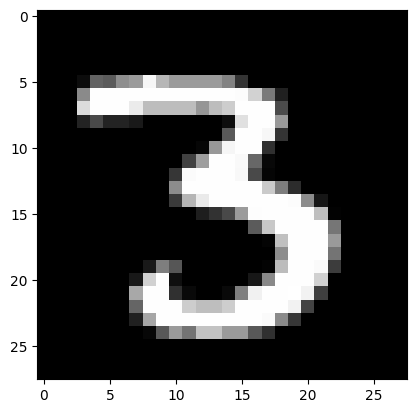

The label is: 3


In [3]:
image_index = 12
pixels = images[image_index].reshape((28, 28))
plt.imshow(pixels, cmap='gray')
plt.show()
print("The label is:", labels[image_index])

Now it's time to implement the forward pass, along with ReLU and softmax. We will return all intermediate values ($z_1,a_1,z_2$) in addition to the final output $a_2$ for backpropagation later.

In [4]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    z = x - np.max(x)
    numerator = np.exp(z)
    exp_sum = np.sum(numerator)
    return numerator / exp_sum

# x is the input vector
def forward(x, W1, b1, W2, b2):
    z1 = np.matmul(W1, x) + b1
    a1 = relu(z1)

    z2 = np.matmul(W2, a1) + b2
    a2 = softmax(z2)

    return z1, a1, z2, a2

OK, before we continue it's important that the labels are encoded in the right format. Currently they are discrete values: $0$, $1$, etc. We want to encode the labels as vector in $\mathbb R^{10}$, with the "correct" entry set to $1$. This is called **one-hot encoding**, because in each label vector, only one entry is "hot" (set to 1).

The reason we want the labels to be encoded this way is so that we can easily compute a *loss* (error) from each forward pass. Remember that the forward pass also returns a vector in $\mathbb R^{10}$ whose entries indicate the probability the image is the corresponding number.

For example, the label "$3$" is encoded as:
\begin{equation}
    \begin{bmatrix}
        0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0
    \end{bmatrix}^T
\end{equation}
Note: I am including a transpose so that the label is a column vector.

In [5]:
labels_1hot = np.zeros((len(labels), 10))
for i in range(len(labels)):
    labels_1hot[i][labels[i]] = 1

labels_test_1hot = np.zeros((len(labels_test), 10))
for i in range(len(labels_test)):
    labels_test_1hot[i][labels_test[i]] = 1
    
labels_1hot[image_index]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

Now it's time to define the *loss function*, which basically measures how bad the prediction from the forward pass is. We can do this now that we have the one-hot labels that have the same dimensions as the result of the forward pass.

*Cross-entropy loss* is pretty much the gold standard now since it behaves well with gradient descent. Let $t\in\mathbb R^{10}$ be the one-hot encoding (label/"correct" value) and let $y\in\mathbb R^{10}$ be the prediction from the neural network (i.e. $\sigma(z_2)$ from the forward pass).
\begin{equation}
    L(t,y)=-t^T (\ln y)=-t\cdot\ln y
\end{equation}
$\ln y$ is a vector in $\mathbb R^{10}$ and is the element wise natural logarithm of the $y$ vector. That is, the $i$th entry of $\ln y$ is equal to $\ln(y_i)$.

Implementation notes:
- The `np.log` function is base $e$ by default. It functions as the element wise natural logarithm.
- We will actually calculate $\ln (y_i+10^{-7})$ instead of $\ln(y_i)$. We are adding a small amount so that we do not evaluate the undefined value $\ln0$ if $y_i=0$.
- In NumPy, `a * b` is the pairwise product of two vector/matrices/arrays. `np.sum` will sum the entries and return a scalar. This is how cross-entropy loss is usually implemented in NumPy for dimensionality (array shape) reasons.

In [6]:
def cross_entropy_loss(t, y):
    return -np.sum(t * np.log(y + 1e-7))

cross_entropy_loss(
    np.array([0.0, 0.0, 1.0]),
    np.array([0.1, 0.0, 0.9])
)

np.float64(0.1053604045467214)

Now that we have all the preliminary stuff done, it's time to implement gradients and backpropagation. Backpropagation is the process where we find the errors (i.e. compute the gradient of the loss with respect to earlier parameters using the multivariable chain rule) in the earlier stages (before where the cross-entropy loss is calculated) to update the weights in $W_1,b_1,W_2,b_2$.

Note on notation: usually in math, the entry in the $i$'th row and $j$'th column in a matrix $A$ is $A_{ij}$, and the $i$'th entry in a vector $v$ is $v_i$. We already have a lot of subscripts so to simplify/clarify notation, I will use "programming notation":
\begin{equation*}
    A_{ij}=A[i,j]
    \qquad v_i=v[i]
\end{equation*}

**Gradient descent.** This is an optimization method we will be using. We can use this to find absolute minima of convex functions. These are functions for which a line, plane or equivalent in higher dimensions between any two points would lie above the curve itself. Essentially it is a "cup" that opens upwards.

This will work in any number of dimensions, but let's use 3D as an example. Suppose $z=F(x,y)$ defines a convex surface in 3D. Pick any point $(x_1,y_1,z_1)$ and evaluate the gradient $\nabla F$ at that point. Since the gradient points in the direction of steepest change,
\begin{equation*}
    (x_2,y_2)=(x_1,y_1)-\alpha\nabla F(x_1,y_1)
\end{equation*}
will be closer to the absolute minimum. $\alpha$ is a scalar constant known as the *learning rate*, which is how much we will update in each step.

We are using a minus sign because the gradient points in the direction of highest/most positive change.

Now let's apply this to the neural network. Note that the loss function we are optimizing is not convex (the real world is a lot more complicated...), but gradient descent will converge upon a local/relative minimum that will be enough to train a decent model.

Suppose we are updating the weights of $W_2$, which is a $10\times 512$ matrix.
\begin{equation*}
    W_2 \leftarrow W_2-\alpha \frac{\partial L}{\partial W_2}
\end{equation*}
$L$ is the loss function. We want to minimize $L$ because a lower loss means the model is more accurate. I am using the left arrow symbol ($\leftarrow$) for assignment. As before, $\alpha$ is the learning rate.

OK, what does it mean to calculate the partial derivative with respect to a matrix? It is shorthand for how each entry of the $W_2$ matrix is updated:
\begin{equation*}
    W_2[i,j]\leftarrow W_2[i,j]-\alpha \frac{\partial L}{\partial W_2[i,j]}
\end{equation*}
Everything in this equation is a scalar value now.

The next steps are clear now. There are 4 parameters that need to be optimized: $W_1,b_1,W_2,b_2$. We need to find the partial derivative of loss with respect to each of these to update them by gradient descent.
\begin{equation*}
    \frac{\partial L}{\partial W_1},
    \frac{\partial L}{\partial b_1},
    \frac{\partial L}{\partial W_2},
    \frac{\partial L}{\partial b_2},
\end{equation*}
As before, this is shorthand for the partial derivative with respect to each of the entries. Each of the above have the same dimensions as $W_1,b_1,W_2,b_2$, respectively. This means we can update them by gradient descent as described above.

Note: the derivations below are basically directly from source 8 (Medium article). All the derivations below will be used in the backward pass (`backward` function).

**Loss w.r.t. $z_2$.** Before we calculate these, we first need to calculate $\partial L/\partial z_2$. We will denote this as $\delta_2$. $\delta_2$ is a vector in $\mathbb R^{10}$. To calculate it, we need to calculate each individual component. We will denote the one-hot label vector as $t$.
\begin{equation*}
    \delta_2[n]
    =\frac{\partial L}{\partial z_2[n]}
\end{equation*}
It's going to be easier to find this in terms of the post=softmax vector $a_2$ instead. But $L$ depends on every entry of $a_2$ ($L$ can be thought of as having 10 parameters for each entry of $a_2$), not just the $n$'th. We will apply the multivariable chain rule here.
\begin{equation*}
    \delta_2[n]
    =\sum_{i=1}^{10}\frac{\partial L}{\partial a_2[i]}\frac{\partial a_2[i]}{\partial z_2[n]}
\end{equation*}
I will stop indicating the bounds of the summation to reduce clutter. It will be easier to break the summation into two separate terms: one where $i=n$ and one where $i\neq n$.
\begin{equation*}
    \delta_2[n]
    =\sum_{i\neq n}\frac{\partial L}{\partial a_2[i]}\frac{\partial a_2[i]}{\partial z_2[n]}+\frac{\partial L}{\partial a_2[n]}\frac{\partial a_2[n]}{\partial z_2[n]}
\end{equation*}
Let's leave this here for now and consider the value of each of these partial derivatives. The definition of cross-entropy loss $L$:
\begin{equation*}
    L(t,y)
    =-t\cdot \ln y
    =-\sum_{m=1}^{10}t[m]\ln(y[m])
\end{equation*}
Now recall that we are calculating the cross-entropy loss on the post-activation vector $a_2$; that is, we are evaluating $L(t,a_2)$. So the partial derivative of $L$ with respect to entries of $a_2$ is straightforward.
\begin{equation*}
    \frac{\partial L}{\partial a_2[n]}
    =\frac{\partial}{\partial a_2[n]}\left( -\sum_{m=1}^{10}t[m]\ln(a_2[m]) \right)
\end{equation*}
Only one of these terms change with respect to $a_2[n]$; the rest are constants and the derivative evaluates to zero.
\begin{equation*}
    \frac{\partial L}{\partial a_2[n]}
    =\frac{\partial}{\partial a_2[n]}\left( -t[n]\ln(a_2[n]) \right)
    =-\frac{t[n]}{a_2[n]}
\end{equation*}
This can be generalized to the partial derivative of $L$ with respect to any entry of $a_2$:
\begin{equation*}
    \frac{\partial L}{\partial a_2[i]}
    =-\frac{t[i]}{a_2[i]}
\end{equation*}
This happens to another of the partial derivatives in the equation we need to find.

Next, the partial derivative of entries of $a_2$ with respect to entries of $z_2$. Recall that $a_2=\sigma(z_2)$, where $\sigma$ is the softmax function defined as such:
\begin{equation*}
    a_2[i]=\sigma(z_2)[i]=\frac{\exp(z_2[i])}{\sum_j \exp(z_2[j])}
\end{equation*}
The partial derivative is pretty straightforward then.
\begin{equation*}
    \frac{\partial a_2[n]}{\partial z_2[n]}
    =\frac{\partial}{\partial z_2[n]}\left( \frac{\exp(z_2[n])}{\sum_j \exp(z_2[j])} \right)
\end{equation*}
Time to use the quotient rule.
\begin{align*}
    \frac{\partial a_2[n]}{\partial z_2[n]}
    &=\frac{\exp(z_2[n])\sum_j \exp(z_2[j]) - \exp(z_2[n])\exp(z_2[n])}{\left( \sum_j \exp(z_2[j]) \right)^2} \\
    &=\frac{\exp(z_2[n])}{\sum_j \exp(z_2[j])} - \frac{(\exp(z_2[n]))^2}{\left(\sum_j \exp(z_2[j])\right)^2} \\
    &=\frac{\exp(z_2[n])}{\sum_j \exp(z_2[j])}\left( 1 - \frac{\exp(z_2[n])}{\sum_j \exp(z_2[j])} \right)
\end{align*}
The definition of the softmax appears twice above. $a_2[n]$ can be substituted for each.
\begin{equation*}
    \frac{\partial a_2[n]}{\partial z_2[n]}
    =a_2[n](1-a_2[n])
\end{equation*}
And last, we need to find $\partial a_2[i]/\partial z_2[n]$. Please trust me that the result (feel free to work out the quotient rule) is:
\begin{equation*}
    \frac{\partial a_2[i]}{\partial z_2[n]}
    =\frac{\partial}{\partial z_2[n]}\sigma(z_2[i])
    =-a_2[i]a_2[n]
\end{equation*}

Now substituting all of these results into the expression for $\delta_2[n]$:
\begin{align*}
    \delta_2[n]
    &=\sum_{i\neq n}\frac{\partial L}{\partial a_2[i]}\frac{\partial a_2[i]}{\partial z_2[n]}+\frac{\partial L}{\partial a_2[n]}\frac{\partial a_2[n]}{\partial z_2[n]} \\
    &=\sum_{i\neq n}\left( -\frac{t[i]}{a_2[i]} \right)\left( -a_2[i]a_2[n] \right)+\left(-\frac{t[n]}{a_2[n]}\cdot a_2[n](1-a_2[n])\right) \\
    &=\sum_{i\neq n}t[i]a_2[n]-t[n](1-a_2[n]) \\
    &=\sum_{i\neq n}t[i]a_2[n]-t[n]+t[n]a_2[n]
\end{align*}
Now we can move the $t[n]a_2[n]$ inside the summation and remove the condition that $i\neq n$.
\begin{align*}
    \delta_2[n]
    &=\sum_{i}t[i]a_2[n]-t[n] \\
    &=a_2[n]\sum_{i}t[i]-t[n]
\end{align*}
Recall that $t$ is one-hot: exactly one entry equals $1$, everything else is $0$. Since $1\leq i\leq 10$, this means that $\sum_i t[i]=1$.
\begin{equation*}
    \delta_2[n]
    =a_2[n]-t[n]
\end{equation*}
$\delta_2,a_2,t$ all have the same dimensions (all $10$). Now we have an expression for the whole $\delta_2$ vector, which is probably much simpler than expected:
\begin{equation*}
    \boxed{\delta_2=a_2-t}
\end{equation*}


**Loss w.r.t. $W_2$.** $\partial L/\partial W_2$. This is a matrix with the same dimensions as $W_2$, which is $10\times 512$. Each entry of this matrix is:
\begin{equation*}
    \frac{\partial L}{\partial W_2}[i,j]
    = \frac{\partial L}{\partial W_2[i,j]}
\end{equation*}
We can use the chain rule. The "intermediate" variable is an entry of $z_2$. We are only considering the $W_2[i,j]$ entry, and due to how matrix multiplication works (remember that $z_2=W_2a_1+b_2$), only the $i$'th entry in $z_2$ is affected. The bias term is constant with respect to $W_2$ so it does not need to be considered.
\begin{align*}
    \frac{\partial L}{\partial W_2}[i,j]
    &=\frac{\partial L}{\partial z_2[i]}\frac{\partial z_2[i]}{\partial W_2[i,j]} \\
    &=\left(\frac{\partial L}{\partial z_2[i]}\right)\frac{\partial}{\partial W_2[i,j]}\left(W_2a_1+b_2\right)[i]
\end{align*}
Maybe a small abuse of notation here: the trailing brackets means "the $i$'th entry of the vector in the parentheses, which is the value we are calculating the partial derivative of. As mentioned before bias is constant so we can remove it.

Note on dimensionality: $1\leq i\leq 10,1\leq j\leq 512$, $a_1$ has $512$ dimensions.
\begin{equation*}
    \frac{\partial L}{\partial W_2}[i,j]
    =\left(\frac{\partial L}{\partial z_2[i]}\right)\frac{\partial}{\partial W_2[i,j]}\left(W_2a_1\right)[i]
\end{equation*}
From matrix multiplication, the $i$'th entry of $W_2a_1$ is the dot product of the $i$'th row of $W_2$ and $a_1$. Algebraically:
\begin{equation*}
    (W_2a_1)[i]
    =(\text{row $i$ of $W_2$})\cdot a_1
    =\sum_{m=1}^{512}W_2[i,m]a_1[m]
\end{equation*}
Substituting this back into the equation:
\begin{align*}
    \frac{\partial L}{\partial W_2}[i,j]
    &=\left(\frac{\partial L}{\partial z_2[i]}\right)\frac{\partial}{\partial W_2[i,j]}\left(W_2a_1\right)[i] \\
    &=\left(\frac{\partial L}{\partial z_2[i]}\right)\frac{\partial}{\partial W_2[i,j]}\sum_{m=1}^{512}W_2[i,m]a_1[m]
\end{align*}
As before, every term of the sum is constant with respect to $W_2[i,j]$ except for one, which is the one when $m=j$.
\begin{align*}
    \frac{\partial L}{\partial W_2}[i,j]
    &=\left(\frac{\partial L}{\partial z_2[i]}\right)\frac{\partial}{\partial W_2[i,j]}W_2[i,j]a_1[j] \\
    &=\left(\frac{\partial L}{\partial z_2[i]}\right)a_1[j]
\end{align*}
Conveniently, $\partial L/\partial z_2[i]$ is the $i$'th term of $\delta_2$ we calculated earlier.
\begin{equation*}
    \frac{\partial L}{\partial W_2}[i,j]
    =\delta_2[i]a_1[j]
\end{equation*}
So row $i$, column $j$ of the $\partial L/\partial W_2$ matrix is: the product of the $i$'th entry of $\delta_2$ and the $j$'th entry of $a_1$. This can be expressed with the [*outer product*](https://en.wikipedia.org/wiki/Outer_product#Definition). The outer product can also be written in terms of transposes: if $a,b$ are column vectors, the outer product $a\otimes b=ab^T$. If $a\in\mathbb R^m$ and $b\in\mathbb R^n$, then $a\otimes b$ is a $m\times n$ matrix.
\begin{equation*}
    \boxed{\frac{\partial L}{\partial W_2}
    =\delta_2 \otimes a_1
    =\delta_2(a_1)^T}
\end{equation*}
We know that $\delta_2\in\mathbb R^{10}$ and $a_1\in\mathbb R^{512}$, meaning that $\partial L/\partial W_2$ is a $10\times 512$ matrix. $W_2$ is also a $10\times 512$ matrix. Their dimensions match (which we need for gradient descent), which is good.

**Loss w.r.t. $b_2$.** I will handwave the component/entry math before because it's pretty simple.
\begin{align*}
    \frac{\partial L}{\partial b_2}
    &=\frac{\partial L}{\partial z_2}\frac{\partial z_2}{\partial b_2} \\
    &=\delta_2 \frac{\partial}{\partial b_2}(W_2a_1+b_2) \\
    &=\delta_2 \left(\frac{\partial}{\partial b_2}(W_2a_1)+\frac{\partial}{\partial b_2}(b_2)\right) \\
    &=\delta_2 \left(0+1\right)
    =\boxed{\delta_2}
\end{align*}

**Loss w.r.t. $z_1$.** Also known as $\delta_1=\partial L/\partial z_1$.

Let's consider the "pipeline" in the forward pass. It goes like this:
\begin{equation*}
    x
    \rightarrow z_1
    \rightarrow a_1
    \rightarrow z_2
    \rightarrow a_2
    \rightarrow L
\end{equation*}
To calculate $\delta_1$, we're making a "jump" from $z_1$ all the way to $L$. The chain rule is useful here.
\begin{equation*}
    \delta_1
    =\frac{\partial L}{\partial z_1}
    =\frac{\partial L}{\partial z_2}\frac{\partial z_2}{\partial a_1}\frac{\partial a_1}{\partial z_1}
\end{equation*}
Better, since we are evaluating the partial derivative of each value with respect to another value that is "adjacent to it in the pipeline." Note from before that $\partial L/\partial z_2=\delta_2$, and that $a_1=\mathrm{ReLU}(z_1)$.

Now we calculate $\partial z_2/\partial a_1$. Recall that $z_2=W_2a_1+b_2$. Again, handwaving math for individual entries:
\begin{equation*}
    \frac{\partial z_2}{\partial a_1}
    =\frac{\partial}{\partial a_1}(W_2a_1+b_2)
    =W_2
\end{equation*}
Substituting everything in:
\begin{equation*}
    \delta_1
    \stackrel?=\delta_2\left(W_2\right)\left(\frac{\mathrm d}{\mathrm d z_1}\mathrm{ReLU}(z_1)\right)
\end{equation*}
The dimensions don't really work out here. Recall from before, the dimensions are:
 - $\delta_1$ is a vector: $512\times 1$.
 - $\delta_2$ is a vector: $10\times 1$.
 - $W_2$ is a matrix: $10\times 512$ (so its transpose $W_2^T$ is $512\times 10$).
 - $z_1$ is a vector: $512\times 1$; so
 - $\mathrm{ReLU}'(z_1)$ is a vector: $512\times 1$.

Let's rearrange this equation to make the dimensions work out. We need the element wise product ([*Hadamard product*](https://en.wikipedia.org/wiki/Hadamard_product_(matrices))) for the $\mathrm{ReLU}'(z_1)$ term.
\begin{equation*}
    \boxed{\delta_1
    =W_2^T \delta_2 \odot \mathrm{ReLU}'(z_1)}
\end{equation*}
The dimensions do work out here.

Intuition for why we need the element wise product: $\mathrm{ReLU}$ and its derivative act independently on each entry of the $z_1$ vector, and therefore, it's independent for entries in $\delta_1$. Independent in the sense that the entries in $\delta_1$ do not impact any entries other than itself.
\begin{align*}
    \delta_1[n]
    &=(W_2^T\delta_2)[n]\cdot (\mathrm{ReLU}'(z_1))[n] \\
    &=((\text{column $n$ of $W_2$})\cdot\delta_2)[n]\cdot \mathrm{ReLU}'(z_1[n])
\end{align*}
Both terms of the product are scalar values. The equivalent of this for the whole vector would be the element wise product.

**Loss w.r.t. $W_1$.** Now this is simple. Recall that $z_1=W_1x+b_1$, where $x$ is the input vector (the flattened image).
\begin{align*}
    \frac{\partial L}{\partial W_1}
    &=\frac{\partial L}{\partial z_1} \frac{\partial z_1}{\partial W_1} \\
    &=\delta_1 \frac{\partial}{\partial W_1}(W_1x+b_1) \\
    &=\boxed{\delta_1 \otimes x}
\end{align*}
Again, using the outer product to ensure dimensionality: like $W_1$, $\partial L/\partial W_1$ is a $512\times 784$ matrix. $\delta_1\in\mathbb R^{512}$ and $x\in\mathbb R^{784}$, so this all works out.

**Loss w.r.t. $b_1$.**
\begin{align*}
    \frac{\partial L}{\partial b_1}
    &=\frac{\partial L}{\partial z_1} \frac{\partial z_1}{\partial b_1} \\
    &=\delta_1 \frac{\partial}{\partial b_1}(W_1x+b_1) \\
    &=(\delta_1)(1)
    =\boxed{\delta_1}
\end{align*}

**Summary.** We've found all the partial derivatives/gradients we need. To summarize:
\begin{align*}
    \frac{\partial L}{\partial W_1}
    &=\delta_1\otimes x \\
    \frac{\partial L}{\partial b_1}
    &=\delta_1 \\
    \frac{\partial L}{\partial W_2}
    &=\delta_2\otimes a_1 \\
    \frac{\partial L}{\partial b_2}
    &=\delta_2
\end{align*}
where:
\begin{align*}
    \delta_2
    &=\frac{\partial L}{\partial z_2}
    =a_2-t \\
    \delta_1
    &=\frac{\partial L}{\partial z_1}
    =W_2^T\delta_2\odot \mathrm{ReLU}'(z_1)
\end{align*}
One more detail: the derivative of $\mathrm{ReLU}$:
\begin{equation*}
    \mathrm{ReLU}'(x)
    =\begin{cases}
        0 & x < 0 \\
        1 & x > 0
    \end{cases}
\end{equation*}
It's undefined at $x=0$ (look at the graph), but for practical purposes let's just define $\mathrm{ReLU}'(0)=0$.

In the code implementation, `x > 0` does exactly what we want: `x` is a vector, and it will produce a vector with the same dimensionality/shape; the $i$'th entry is $1$ if $x[i] > 0$ and $0$ otherwise.

The `backward` calculates and returns the partial derivatives above. As before, asterisk `*` is the element wise product; if `a` and `b` are both NumPy vectors with the same shape, `a * b` returns $a\odot b$. `np.outer(a, b)` implements the outer product and returns $a\otimes b$.

In [7]:
def relu_deriv(x):
    return x > 0

def backward(x, t, z1, a1, a2, W2):
    delta2 = a2 - t
    wrt_W2 = np.outer(delta2, a1)
    wrt_b2 = delta2

    delta1 = np.matmul(W2.T, delta2) * relu_deriv(z1)
    wrt_W1 = np.outer(delta1, x)
    wrt_b1 = delta1
    
    return wrt_W1, wrt_b1, wrt_W2, wrt_b2

Now, an `update` function to return the parameters updated by gradient descent. `LR` is the learning rate ($\alpha$ earlier).

In [8]:
def update(
        W1,     b1,     W2,     b2,
    wrt_W1, wrt_b1, wrt_W2, wrt_b2,
    LR
):
    return (
        W1 - LR * wrt_W1,
        b1 - LR * wrt_b1,
        W2 - LR * wrt_W2,
        b2 - LR * wrt_b2
    )


Now onto the main training loop. We must initialize the parameters $W_1,b_1,W_2,b_2$ to something. If they are zero, all the gradients will be $0$, and training will totally fail.

There are [here](https://cs231n.github.io/neural-networks-2/) is the recommended way to initialize the parameters. The $W$'s are initialized by a random Gaussian distribution scaled by the number of inputs, and the biases $b$'s are initialized to zero.

I am going to seed the random number generator. The model will depend on what $W_1,b_1,W_2,b_2$ are initialized to, and seeding the RNG should make this deterministic across runs.

In [9]:
np.random.seed(1864)

In [10]:
input_size = 784
hidden_size = 512
output_size = 10

W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2 / input_size)
b1 = np.zeros(hidden_size)

W2 = np.random.randn(output_size, hidden_size) * np.sqrt(2 / hidden_size)
b2 = np.zeros(output_size)

Now, the main training loop. This is pretty simple. Performing each of the following steps on every image in the training dataset is called an *epoch*. The model is then trained for a certain number of epochs; we will use $20$.

The steps on each image are:
1. Obtain the input vector $x$ and the one-hot label vector $t$.
2. Run the forward pass to find $z_1,a_1,z_2,a_2$.
3. (Optional: calculate the cross-entropy loss $L(t,a_2)$ and add them to an accumulated loss variable)
4. Run the backward pass (backpropagation) to find $\partial L/\partial W_1, \partial L/\partial b_1, \partial L/\partial W_2, \partial L/\partial b_2$.
5. Update the parameters $W_1,b_1,W_2,b_2$ using the gradients found in the backward pass by gradient descent.

At the end of the epoch, we can optionally print the accumulated loss to get an idea of how our model is improving. This is reset to $0$ at the start of each epoch. A lower loss is better.

Optimizing the learning rate $\alpha$ is another adventure. I will just set it to $0.001$.

In [11]:
epochs = 20
LR = 0.001

for epoch in range(epochs):
    total_loss = 0

    for i in range(len(images)):
        x = images[i]
        t = labels_1hot[i]

        z1, a1, z2, a2 = forward(
            x, W1, b1, W2, b2
        )
        
        total_loss += cross_entropy_loss(t, a2)
        
        wrt_W1, wrt_b1, wrt_W2, wrt_b2 = backward(
            x, t, z1, a1, a2, W2
        )
        
        W1, b1, W2, b2 = update(
                W1,     b1,     W2,     b2,
            wrt_W1, wrt_b1, wrt_W2, wrt_b2,
            LR
        )

    print(f"epoch {epoch + 1} finished, loss {total_loss}")

epoch 1 finished, loss 23198.84763551201
epoch 2 finished, loss 13029.872685395947
epoch 3 finished, loss 10145.689752499502
epoch 4 finished, loss 8336.578381199664
epoch 5 finished, loss 7066.523599247346
epoch 6 finished, loss 6123.131028195731
epoch 7 finished, loss 5390.860295470171
epoch 8 finished, loss 4801.606824243561
epoch 9 finished, loss 4318.7818850811755
epoch 10 finished, loss 3911.6186333917794
epoch 11 finished, loss 3565.824893907558
epoch 12 finished, loss 3265.029569997117
epoch 13 finished, loss 3002.265271615438
epoch 14 finished, loss 2770.711465180414
epoch 15 finished, loss 2563.7044926581148
epoch 16 finished, loss 2378.8209803701448
epoch 17 finished, loss 2211.4947413470777
epoch 18 finished, loss 2060.221782133409
epoch 19 finished, loss 1922.410902333581
epoch 20 finished, loss 1796.789231320519


Next, we will evaluate the neural network by finding its accuracy on a separate "test" dataset. It's important to evaluate it on a completely different dataset to test how well it generalizes.

Implementing this is also fairly simple. We iterate over the test dataset, find $a_2$, find the $\mathrm{argmax}$ (the entry in the $a_2$ vector with the highest value/probability is the prediction) and check that against the correct label.

In [12]:
correct = 0

for i in range(len(images_test)):
    _, _, _, a2 = forward(
        images_test[i], W1, b1, W2, b2
    )
    
    correct += np.argmax(a2) == labels_test[i]
    
percent = correct / len(images_test)

print(f"{correct} / {len(images_test)}")
print(f"accuracy = {percent * 100}%")

9778 / 10000
accuracy = 97.78%


Increasing the number of epochs does not increase the total loss and test accuracy past a point. There are only so many parameters the model can optimize. In fact, it might actually get worse as the model overfits: it becomes very good at the training set but its parameters do not generalize well to another dataset.

The state of the art accuracy for MNIST number classification is around $99.91\%$ with convolutional neural networks. For a simple fully connected network, around $98\%$ is pretty good.

Just as a demonstration, here is a random image from the test set along with the mode's output vector $a_2$.

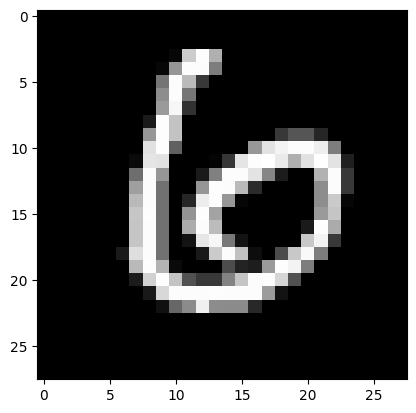

correct: 6
[0.0000403179 0.0000006844 0.0000471531 0.0000010022 0.000001458
 0.0000304909 0.9997710451 0.0000001072 0.0001075555 0.0000001856]


In [13]:
np.set_printoptions(precision=10, suppress=True)

correct_id = 11

pixels = images_test[correct_id].reshape((28, 28))
plt.imshow(pixels, cmap='gray')
plt.show()

_, _, _, a2 = forward(images_test[correct_id], W1, b1, W2, b2)

print("correct:", labels_test[correct_id])
print(a2)

$a_2[4]$ (in $0$ indexed notation) is around $0.999$, so the model predicts the number is a $4$. This is correct.

Here is an example where the model is wrong: image $\#115$ from the test set.

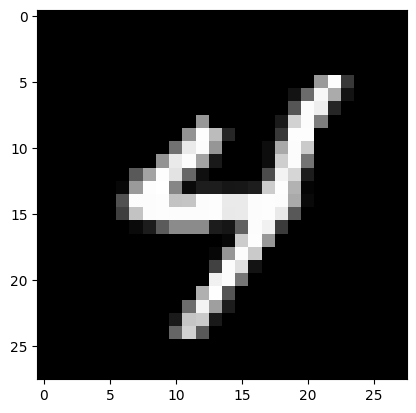

correct: 4
[0.0001117988 0.0016271353 0.000170354  0.0000183998 0.3947839632
 0.000659412  0.002179393  0.0000602739 0.0005597601 0.5998295098]


In [14]:
incorrect_id = 115

pixels = images[incorrect_id].reshape((28, 28))
plt.imshow(pixels, cmap='gray')
plt.show()

_, _, _, a2 = forward(images_test[incorrect_id], W1, b1, W2, b2)
print("correct:", labels_test[incorrect_id])
print(a2)

The number looks badly drawn and resembles both $4$ and $9$, which is what the output of the model says: $a_2[4]=0.3948,a_2[9]=0.5998$. Still the highest value is $a_2[9]$, so the model incorrectly predicts $9$.

If we changed any of the hyperparameters (the parameters used to train the model: RNG seed, learning rate, number of epochs), then the model would be different, and there is a change it would be right in this case (but might get other cases wrong).

**That's all! We have trained a neural network from "first principles" using backpropagation and gradient descent. Thank you for reading!**

**Sources**

1. https://stackoverflow.com/questions/40427435/extract-images-from-idx3-ubyte-file-or-gzip-via-python
2. Stanford CS231n course: https://cs231n.github.io/, many lecture notes used
3. https://courses.cs.washington.edu/courses/cse446/24wi/schedule/lecture_07/gradient_descent.pdf
4. https://www.cs.toronto.edu/~urtasun/courses/CSC411_Fall16/10_nn1.pdf
5. https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/
    - Note: this source does basically the same thing I am trying to do but I am not copying from it directly; you'll notice I am doing a lot of things differently from it.
6. https://alvinntnu.github.io/python-notes/nlp/neural-network-from-scratch.html#loss-functions
7. https://www.cs.toronto.edu/~mren/teach/csc411_19s/lec/lec08_notes.pdf
8. https://medium.com/data-science/deriving-backpropagation-with-cross-entropy-loss-d24811edeaf9
9. https://en.wikipedia.org/wiki/Outer_product#Definition
